In [17]:
import tensorflow as tf
import os
from tensorflow.keras import models, layers

BATCH_SIZE = 32
EPOCHS = 50
input_shape = (256, 256, 3)

def load_dataset(directory):
    """Load dataset dynamically based on the class folders."""
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        label_mode="int",
        batch_size=BATCH_SIZE,
        image_size=(256, 256),
        shuffle=True
    )

def train_disease_model(plant_name, num_classes):
    print(f"Training disease model for {plant_name}...")
    
    base_dir = f"/mnt/home/alwanai/virtualenv/plantVillage"
    train_dataset = os.path.join(base_dir, "train")
    val_dataset = os.path.join(base_dir, "val")
    test_dataset = os.path.join(base_dir, "test")

    ds_train = load_dataset(train_dataset)
    ds_val = load_dataset(val_dataset)
    ds_test = load_dataset(test_dataset)

    ds_train = ds_train.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
    ds_val = ds_val.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
    ds_test = ds_test.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

    resize_and_rescale = tf.keras.Sequential([
        tf.keras.layers.Resizing(256, 256),
        tf.keras.layers.Rescaling(1.0 / 255)
    ])

    # Data augmentation and model for each typeplant
    if plant_name.lower() == "tomato":
        data_augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal_and_vertical"),
            tf.keras.layers.RandomRotation(0.2),
            tf.keras.layers.RandomZoom(0.2),
            tf.keras.layers.RandomContrast(0.2)
        ])
        model = models.Sequential([
            tf.keras.layers.InputLayer(shape=input_shape),
            resize_and_rescale,
            data_augmentation,
            tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(256, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(num_classes, activation='softmax')
        ])

    elif plant_name.lower() == "potato":
        data_augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal_and_vertical"),
            tf.keras.layers.RandomRotation(0.2),
            tf.keras.layers.RandomZoom(0.2),
            tf.keras.layers.RandomContrast(0.2)
        ])
        model = models.Sequential([
            tf.keras.layers.InputLayer(shape=input_shape),
            resize_and_rescale,
            data_augmentation,
            tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(num_classes, activation='softmax')
        ])
    
    elif plant_name.lower() == "bellpepper":
        data_augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal_and_vertical"),
            tf.keras.layers.RandomRotation(0.2)
        ])
        model = models.Sequential([
            tf.keras.layers.InputLayer(shape=input_shape),
            resize_and_rescale,
            data_augmentation,
            tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2,2)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(num_classes, activation='softmax')
        ])

    model.build(input_shape=(None, 256, 256, 3))
    model.summary()

    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    model.fit(
        ds_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        validation_data = ds_val
    )

    model.save(f"{plant_name}_disease_model.keras")
    print(f"{plant_name} disease model saved!")

train_disease_model("Tomato", 15)  
train_disease_model("Potato", 15)  
train_disease_model("BellPepper", 15)  


Training disease model for Tomato...
Found 14441 files belonging to 15 classes.
Found 3089 files belonging to 15 classes.
Found 3110 files belonging to 15 classes.


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_18 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_19 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 750,159 (2.86 MB)

 Trainable params: 750,159 (2.86 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_24 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_25 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,527 (720.81 KB)

 Trainable params: 184,527 (720.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - accuracy: 0.2197 - loss: 2.3514 - val_accuracy: 0.3959 - val_loss: 1.8132
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 45s 100ms/step - accuracy: 0.4527 - loss: 1.6817 - val_accuracy: 0.6070 - val_loss: 1.1646
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 45s 99ms/step - accuracy: 0.6446 - loss: 1.0593 - val_accuracy: 0.7151 - val_loss: 0.8101
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 45s 99ms/step - accuracy: 0.7397 - loss: 0.7682 - val_accuracy: 0.7653 - val_loss: 0.6837
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 45s 99ms/step - accuracy: 0.7832 - loss: 0.6264 - val_accuracy: 0.7546 - val_loss: 0.6904
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 45s 100ms/step - accuracy: 0.8241 - loss: 0.5073 - val_accuracy: 0.8307 - val_loss: 0.4912
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 45s 99ms/step - accuracy: 0.8446 - loss: 0.4478 - val_accuracy: 0.8304 - val_loss: 0.4904
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 45s 100ms/step - accuracy: 0.8615 - loss: 0.401

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

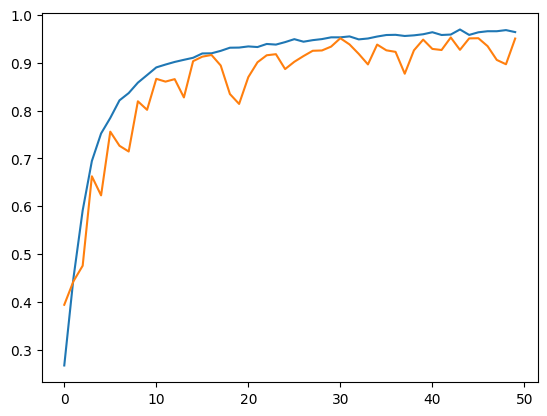

In [19]:
plt.plot(range(len(acc)), acc, label='Training Accuracy')
plt.plot(range(len(val_acc)), val_acc, label='Validation Accuracy')

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9531 - loss: 0.1430
Test Loss: 0.14512597024440765, Test Accuracy: 0.9523962736129761


In [26]:
import tensorflow as tf
import numpy as np

def predict_disease(image_path, plant_type):
    model_path = f"{plant_type}_disease_model.keras"
    disease_model = tf.keras.models.load_model(model_path)
    
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(256, 256))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0) / 255.0 

    prediction = disease_model.predict(img_array)
    
    disease_labels = {
        "Tomato": ["Tomato_Target_Spot", "Tomato_Tomato_mosaic_virus", "Tomato_Tomato_YellowLeaf_Curl_virus", "Tomato_Bacterial_spot", "Tomato_Early_blight","Tomato_healthy","Tomato_Late_blight","Tomato_Leaf_Mold","Tomato_Septoria_leaf_spot","Tomato_Spider_mites_Two_spotted_spider_mite"],
        "Potato": ["Potato__Early_blight", "Potato__healthy", "Potato__Late_blight"],
        "BellPepper": ["Pepper__bell___Bacterial_spot", "Pepper__bell___healthy"]
    }

    predicted_index = np.argmax(prediction)
    if predicted_index >= len(disease_labels[plant_type]):
        print("Error: Model predicted an invalid index.")
        return None

    disease = disease_labels[plant_type][predicted_index]
    print(f"Predicted disease: {disease}")
    return disease

plant_type = "Tomato"

# Testing if it works . this is a path to tomato leaf mold image 
image_path = "/mnt/home/alwanai/virtualenv/plantVillage/test/Tomato_Leaf_Mold/d9c37e93-e99b-4a09-a040-a5d19d75feb9___Crnl_L.Mold 6733.JPG"
disease = predict_disease(image_path, plant_type)

print(f"Result: {plant_type} with {disease}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Predicted disease: Tomato_Leaf_Mold
Result: Tomato with Tomato_Leaf_Mold
